# Matplotlib for Machine Learning Visualization
**Summer of Science 2026 — CS03: Artificial Intelligence and Machine Learning**  
**Mohit Khyalia | IIT Bombay**

---

## Why this notebook

Almost everything in ML that needs to be communicated visually — learning curves, decision boundaries, feature distributions, confusion matrices — uses Matplotlib underneath, even if Seaborn or Pandas wraps it. Understanding the object-oriented Matplotlib API makes it possible to customise any plot rather than accepting defaults.

This notebook focuses on plots that appear directly in ML work:
1. Line plots — for training/validation curves
2. Scatter plots — for data exploration and decision boundaries
3. Histograms — for feature distribution analysis
4. Bar charts — for comparing metrics across models or categories
5. Subplots — for putting multiple plots in one figure
6. Annotating and customising plots for report quality

---

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Style that gives clean, report-ready output
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.size':        11,
})

print('Matplotlib version:', plt.matplotlib.__version__)

Matplotlib version: 3.10.0


## 1. Line Plot — Training and Validation Loss Curve

The most common plot in ML: how does the loss change as training progresses?

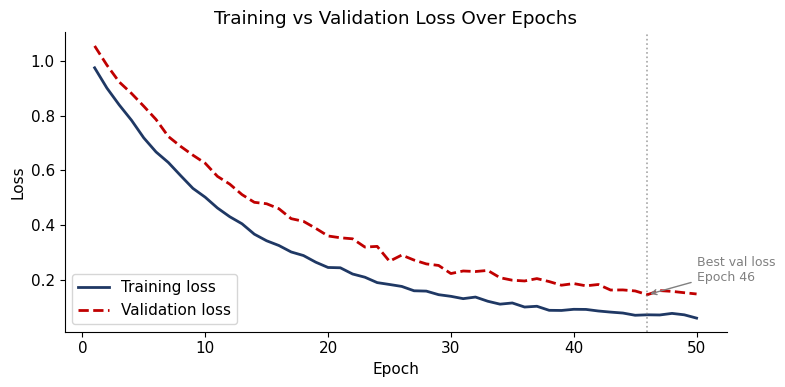

Saved: training_loss_curve.png


In [2]:
np.random.seed(42)

epochs = np.arange(1, 51)

# Simulated training and validation loss
train_loss = 1.0 * np.exp(-0.08 * epochs) + 0.05 + np.random.normal(0, 0.005, 50)
val_loss   = 1.0 * np.exp(-0.07 * epochs) + 0.12 + np.random.normal(0, 0.010, 50)

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(epochs, train_loss, color='#1F3864', lw=2.0, label='Training loss')
ax.plot(epochs, val_loss,   color='#C00000', lw=2.0, linestyle='--', label='Validation loss')

# Mark the epoch with lowest validation loss
best_epoch = epochs[np.argmin(val_loss)]
best_val   = np.min(val_loss)
ax.axvline(best_epoch, color='gray', linestyle=':', lw=1.2, alpha=0.7)
ax.annotate(f'Best val loss\nEpoch {best_epoch}',
            xy=(best_epoch, best_val),
            xytext=(best_epoch + 4, best_val + 0.05),
            arrowprops=dict(arrowstyle='->', color='gray'),
            fontsize=9, color='gray')

ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training vs Validation Loss Over Epochs')
ax.legend()
plt.tight_layout()
plt.savefig('training_loss_curve.png', dpi=150)
plt.show()
print('Saved: training_loss_curve.png')

**Observation:** The validation loss starts higher than training loss and converges more slowly — this is expected and healthy. If validation loss started increasing while training loss kept decreasing, that would be a sign of overfitting.

## 2. Figure-Axes Object Model

Understanding `fig, ax = plt.subplots()` vs `plt.plot()` directly is important for building multi-panel figures.

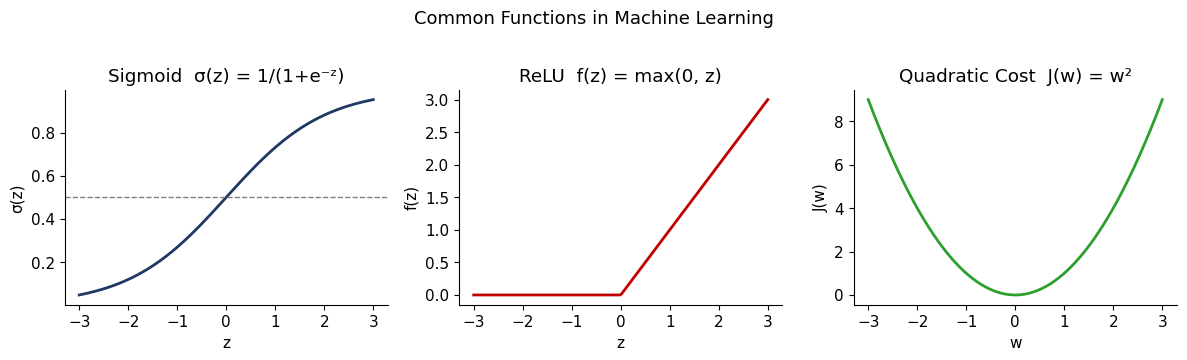

In [3]:
# The object-oriented way (preferred for anything beyond a quick plot)

x = np.linspace(-3, 3, 200)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

# Subplot 1: Sigmoid (Logistic Regression activation)
sigmoid = 1 / (1 + np.exp(-x))
axes[0].plot(x, sigmoid, color='#1F3864', lw=2)
axes[0].axhline(0.5, color='gray', linestyle='--', lw=1)
axes[0].set_title('Sigmoid  σ(z) = 1/(1+e⁻ᶻ)')
axes[0].set_xlabel('z')
axes[0].set_ylabel('σ(z)')

# Subplot 2: ReLU (common neural network activation)
relu = np.maximum(0, x)
axes[1].plot(x, relu, color='#C00000', lw=2)
axes[1].set_title('ReLU  f(z) = max(0, z)')
axes[1].set_xlabel('z')
axes[1].set_ylabel('f(z)')

# Subplot 3: Quadratic cost (MSE intuition)
cost = x**2
axes[2].plot(x, cost, color='#2CA02C', lw=2)
axes[2].set_title('Quadratic Cost  J(w) = w²')
axes[2].set_xlabel('w')
axes[2].set_ylabel('J(w)')

fig.suptitle('Common Functions in Machine Learning', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('ml_functions.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Scatter Plot — Feature Exploration and Class Separation

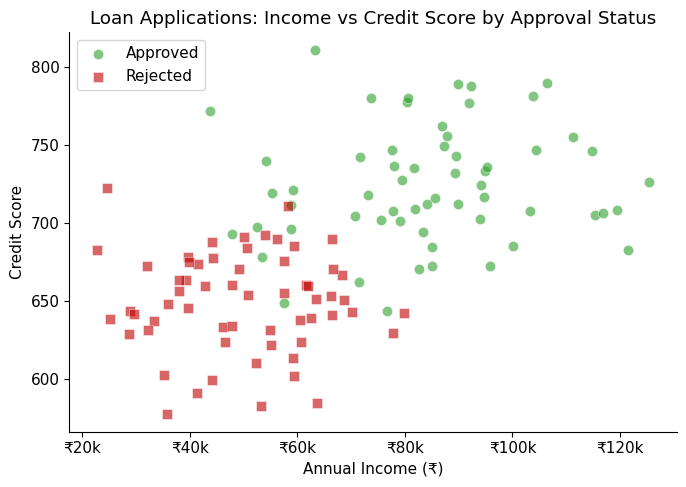

In [4]:
np.random.seed(7)

# Two classes: approved (1) and rejected (0) loans
n = 60
approved_income = np.random.normal(85000, 18000, n)
approved_credit = np.random.normal(720,   40,    n)

rejected_income = np.random.normal(52000, 15000, n)
rejected_credit = np.random.normal(650,   35,    n)

fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(approved_income, approved_credit,
           color='#2CA02C', alpha=0.6, s=55, label='Approved', edgecolors='white', lw=0.5)
ax.scatter(rejected_income, rejected_credit,
           color='#C00000', alpha=0.6, s=55, label='Rejected',  edgecolors='white', lw=0.5,
           marker='s')

ax.set_xlabel('Annual Income (₹)')
ax.set_ylabel('Credit Score')
ax.set_title('Loan Applications: Income vs Credit Score by Approval Status')
ax.legend()

# Format x-axis to show income in lakhs
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'₹{x/1000:.0f}k'))

plt.tight_layout()
plt.savefig('scatter_loan.png', dpi=150)
plt.show()

**Observation:** Approved applications tend to cluster in the upper-right (higher income and credit score). Rejected ones cluster in the lower-left. The classes overlap in the middle — that overlap is exactly what the model has to learn to navigate. If the classes were perfectly separable, a simple threshold would suffice and no ML would be needed.

## 4. Histograms — Feature Distribution Analysis

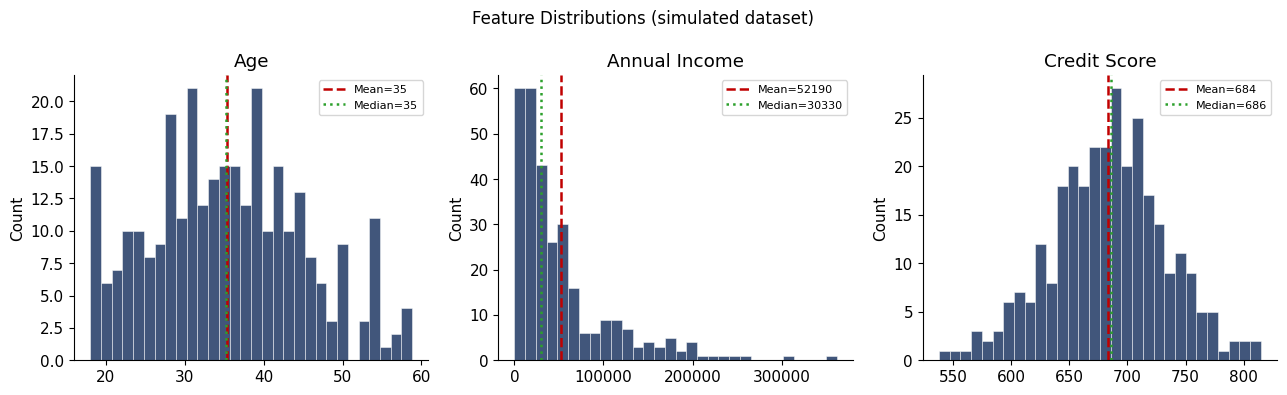

In [5]:
np.random.seed(0)

# Simulating three features with different distribution shapes
age          = np.random.normal(35, 10, 300).clip(18, 70)
income       = np.random.exponential(50000, 300)            # right-skewed
credit_score = np.random.normal(690, 50, 300).clip(300, 850)

features = {'Age': age, 'Annual Income': income, 'Credit Score': credit_score}

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, (name, values) in zip(axes, features.items()):
    ax.hist(values, bins=30, color='#1F3864', edgecolor='white', linewidth=0.4, alpha=0.85)
    ax.axvline(np.mean(values),   color='#C00000', lw=1.8, linestyle='--', label=f'Mean={np.mean(values):.0f}')
    ax.axvline(np.median(values), color='#2CA02C', lw=1.8, linestyle=':',  label=f'Median={np.median(values):.0f}')
    ax.set_title(name)
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

fig.suptitle('Feature Distributions (simulated dataset)', fontsize=12)
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150)
plt.show()

**Observation:** Age and Credit Score look approximately normal (mean ≈ median). Income is right-skewed (mean > median) — a classic pattern for income data where a small number of high earners pull the mean upward. For a Linear Regression model, this skew may be worth addressing with a log transformation, since the model assumes a roughly linear relationship between features and the target.

## 5. Bar Chart — Comparing Model Metrics

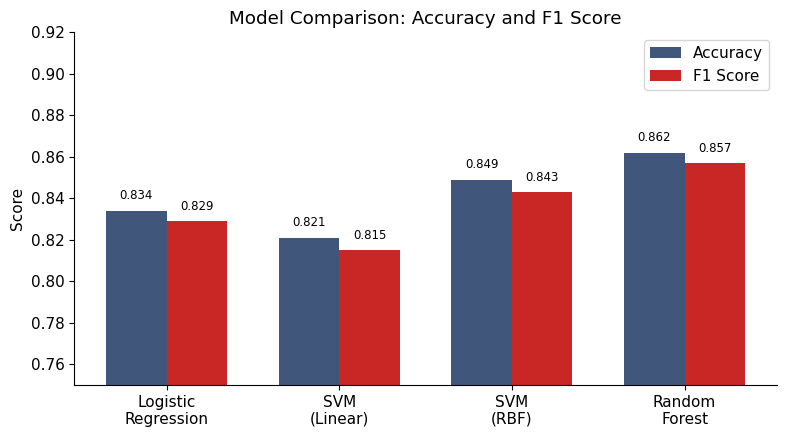

In [6]:
models   = ['Logistic\nRegression', 'SVM\n(Linear)', 'SVM\n(RBF)', 'Random\nForest']
accuracy = [0.834, 0.821, 0.849, 0.862]
f1_score = [0.829, 0.815, 0.843, 0.857]

x      = np.arange(len(models))
width  = 0.35

fig, ax = plt.subplots(figsize=(8, 4.5))

bars1 = ax.bar(x - width/2, accuracy, width, label='Accuracy', color='#1F3864', alpha=0.85)
bars2 = ax.bar(x + width/2, f1_score, width, label='F1 Score', color='#C00000',  alpha=0.85)

# Add value labels on top of each bar
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.004,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8.5)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.004,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8.5)

ax.set_ylim(0.75, 0.92)
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylabel('Score')
ax.set_title('Model Comparison: Accuracy and F1 Score')
ax.legend()

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

**Observation:** Grouped bar charts are the standard way to compare multiple metrics across models. Setting `ylim` to a range near the actual values (0.75–0.92 here) makes differences visible — if the y-axis started at 0, all bars would look nearly identical despite the meaningful performance gaps.

## 6. Subplots — EDA Dashboard Layout

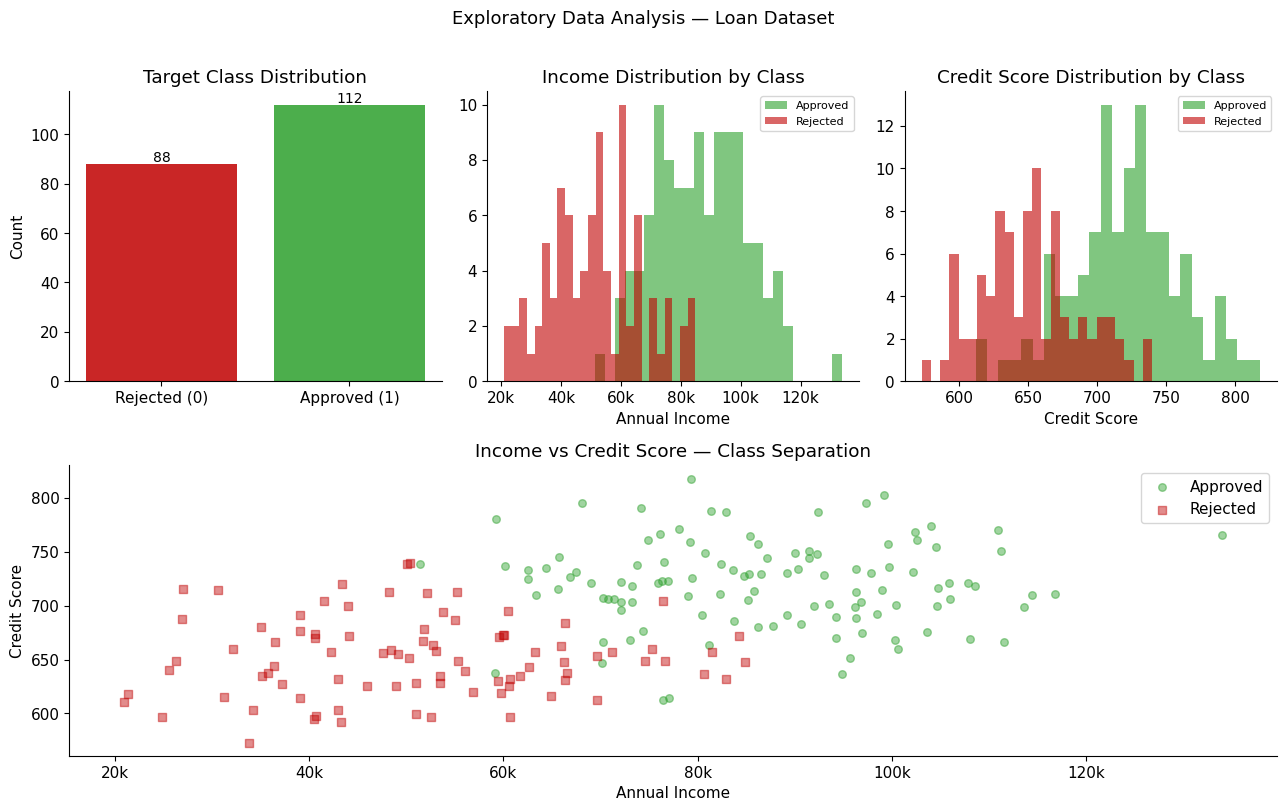

In [7]:
np.random.seed(42)
n = 200

# Synthetic dataset
approved = np.random.choice([0, 1], size=n, p=[0.38, 0.62])
income_vals   = np.where(approved, np.random.normal(85000, 18000, n),
                                    np.random.normal(52000, 15000, n))
credit_vals   = np.where(approved, np.random.normal(720, 40, n),
                                    np.random.normal(650, 35, n))

fig = plt.figure(figsize=(13, 8))
fig.suptitle('Exploratory Data Analysis — Loan Dataset', fontsize=13, y=1.01)

# Panel 1: Class distribution
ax1 = fig.add_subplot(2, 3, 1)
classes, counts = np.unique(approved, return_counts=True)
ax1.bar(['Rejected (0)', 'Approved (1)'], counts, color=['#C00000', '#2CA02C'], alpha=0.85)
for i, c in enumerate(counts):
    ax1.text(i, c + 1, str(c), ha='center', fontsize=10)
ax1.set_title('Target Class Distribution')
ax1.set_ylabel('Count')

# Panel 2: Income histogram by class
ax2 = fig.add_subplot(2, 3, 2)
ax2.hist(income_vals[approved == 1], bins=25, alpha=0.6, color='#2CA02C', label='Approved')
ax2.hist(income_vals[approved == 0], bins=25, alpha=0.6, color='#C00000', label='Rejected')
ax2.set_title('Income Distribution by Class')
ax2.set_xlabel('Annual Income')
ax2.legend(fontsize=8)
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

# Panel 3: Credit score histogram by class
ax3 = fig.add_subplot(2, 3, 3)
ax3.hist(credit_vals[approved == 1], bins=25, alpha=0.6, color='#2CA02C', label='Approved')
ax3.hist(credit_vals[approved == 0], bins=25, alpha=0.6, color='#C00000', label='Rejected')
ax3.set_title('Credit Score Distribution by Class')
ax3.set_xlabel('Credit Score')
ax3.legend(fontsize=8)

# Panel 4: Scatter — income vs credit score
ax4 = fig.add_subplot(2, 1, 2)
ax4.scatter(income_vals[approved == 1], credit_vals[approved == 1],
            c='#2CA02C', alpha=0.45, s=30, label='Approved')
ax4.scatter(income_vals[approved == 0], credit_vals[approved == 0],
            c='#C00000', alpha=0.45, s=30, label='Rejected', marker='s')
ax4.set_xlabel('Annual Income')
ax4.set_ylabel('Credit Score')
ax4.set_title('Income vs Credit Score — Class Separation')
ax4.legend()
ax4.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

plt.tight_layout()
plt.savefig('eda_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

**Observation:** This four-panel layout is a template for EDA dashboards used throughout the mini-projects. Each panel answers a different question:
- Panel 1: Is the dataset balanced?
- Panels 2 & 3: Does each feature separate the classes?
- Panel 4: Do two features together separate the classes better than either alone?

## 7. Gradient Descent Visualization — Connecting Matplotlib to ML Concepts

Starting w=7.00, cost=21.25
Final   w=2.5011, cost=1.000001
True minimum: w=2.5, cost=1.0


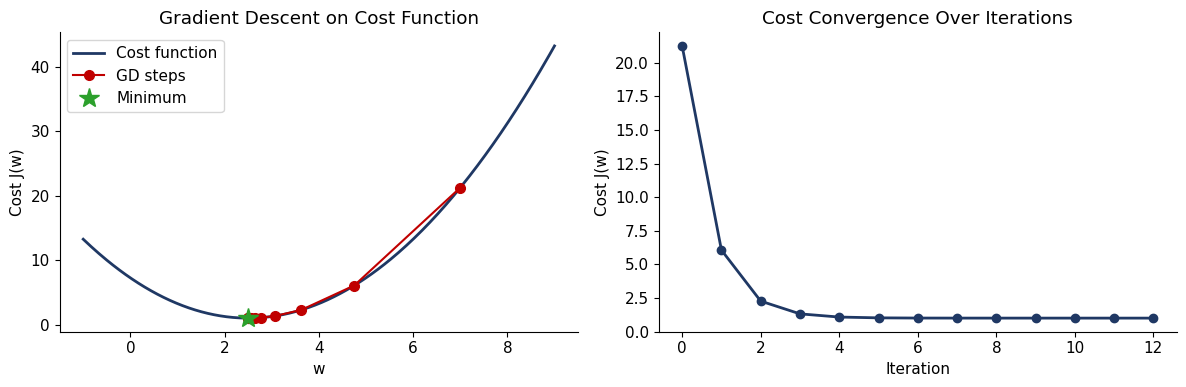

In [8]:
# Visualise how gradient descent iteratively finds the minimum of a cost function

def cost(w):
    return (w - 2.5)**2 + 1

def gradient(w):
    return 2 * (w - 2.5)

# Run gradient descent
w = 7.0       # starting point (far from minimum)
lr = 0.25     # learning rate
history_w = [w]
history_c = [cost(w)]

for _ in range(12):
    w = w - lr * gradient(w)
    history_w.append(w)
    history_c.append(cost(w))

# Plot
w_range = np.linspace(-1, 9, 300)
c_range = cost(w_range)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: cost function with descent path
axes[0].plot(w_range, c_range, color='#1F3864', lw=2, label='Cost function')
axes[0].plot(history_w, history_c, 'o-', color='#C00000', markersize=7, lw=1.5, label='GD steps')
axes[0].plot(2.5, 1, '*', color='#2CA02C', markersize=15, zorder=5, label='Minimum')
axes[0].set_xlabel('w')
axes[0].set_ylabel('Cost J(w)')
axes[0].set_title('Gradient Descent on Cost Function')
axes[0].legend()

# Right: cost vs iteration
axes[1].plot(range(len(history_c)), history_c, 'o-', color='#1F3864', markersize=6, lw=2)
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Cost J(w)')
axes[1].set_title('Cost Convergence Over Iterations')

print(f'Starting w={7.0:.2f}, cost={cost(7.0):.2f}')
print(f'Final   w={history_w[-1]:.4f}, cost={history_c[-1]:.6f}')
print(f'True minimum: w=2.5, cost=1.0')

plt.tight_layout()
plt.savefig('gradient_descent_viz.png', dpi=150)
plt.show()

**Observation:** This visualization is useful preparation for the Week 4 Linear Regression notebook, where the same concept is implemented for higher-dimensional parameter spaces. Here it is easy to see the descent path because the cost function is plotted directly. In higher dimensions, only the iteration vs cost curve is feasible to plot.

---

## Summary

| Plot type | When to use | Key parameters |
|---|---|---|
| Line plot | Training/validation curves, any sequential data | `lw`, `linestyle`, `label` |
| Scatter plot | Feature relationships, decision boundaries | `c`, `alpha`, `marker`, `s` |
| Histogram | Feature distributions, class overlap | `bins`, `alpha`, overlay two classes |
| Bar chart | Metric comparison across models/categories | `width`, `x ± width/2` for grouped |
| Subplots | EDA dashboards, multi-metric displays | `fig.add_subplot()` or `plt.subplots(r,c)` |

The key habit: always set axis labels, a title, and call `plt.tight_layout()` before saving. Plots without labels are not useful in a report.

---
*Notebook — Mohit Khyalia, Summer of Science 2026, IIT Bombay*